In [1]:
import numpy as np 
import pandas as pd
import scanpy as sc

In [2]:
df_mac = pd.read_csv('/home/chzhan1/Python/SAiGENCI/df_data/df_mac.csv')
df_mac.set_index('sample_names', inplace=True)

metadata = pd.read_csv('/home/chzhan1/Python/SAiGENCI/df_data/metadata.csv')
metadata.columns.values[0] = 'sample_names'
metadata.set_index('sample_names', inplace=True)

In [3]:
df_mac_01 = pd.read_csv('/home/chzhan1/Python/SAiGENCI/df_data/df_mac_01.csv')
df_mac_01.set_index('sample_names', inplace = True)

In [4]:
# Calculate the fraction of samples for which each gene is sequenced
gene_presence_fraction = df_mac_01.mean(axis=0)
gene_presence_fraction

ENSG00000238009    0.711596
ENSG00000239945    0.552711
ENSG00000228463    0.491340
ENSG00000237094    0.438253
ENSG00000230021    0.440136
                     ...   
ERCC-00054         0.000000
ERCC-00040         0.000000
ERCC-00145         0.000000
ERCC-00143         0.000000
ERCC-00163         0.000000
Length: 60621, dtype: float64

In [5]:
threshold = 0.6
selected_gene_list = gene_presence_fraction[gene_presence_fraction >= threshold]
selected_gene_list = selected_gene_list.index.to_list()
len(selected_gene_list)

32282

In [6]:
df = df_mac[selected_gene_list]
df

,ENSG00000238009,ENSG00000237491,ENSG00000177757,ENSG00000225880,ENSG00000230368,ENSG00000230699,ENSG00000241180,ENSG00000223764,ENSG00000187634,ENSG00000188976,...,ENSG00000285492,ENSG00000279342,ENSG00000267226,ENSG00000257127,ENSG00000183242,ENSG00000255920,ENSG00000254166,ENSG00000274020,ENSG00000219410,ENSG00000257557
sample_names,,,,,,,,,,,,,,,,,,,,,
03d9eb203bc24f826a30525d2e4d155a___macrophage,222.751792,222.751792,222.751792,222.751792,222.751792,222.751792,222.751792,222.751792,222.751792,14601.313188,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
70a3087e85d17f6a27a3cb6949190c21___macrophage,163.912914,163.912914,163.912914,163.912914,163.912914,163.912914,163.912914,163.912914,163.912914,10341.103105,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
129df572f839feb0392d1a386408fe6f___macrophage,0.000000,72843.263715,727.510070,727.510070,727.510070,727.510070,727.510070,727.510070,727.510070,20679.312547,...,727.510070,727.510070,727.510070,727.510070,727.510070,727.510070,727.510070,36073.496157,32869.947563,727.510070
a654c8dcf70f0c397cec83474dc30eba___macrophage,0.000000,35593.088461,527.863516,527.863516,527.863516,527.863516,527.863516,527.863516,527.863516,29944.520249,...,14584.905906,527.863516,527.863516,527.863516,527.863516,14584.905906,527.863516,43153.725420,527.863516,14584.905906
cfe04fd6b8efbedb43298f57f8bb7531___macrophage,0.000000,25145.192378,508.594844,508.594844,508.594844,508.594844,508.594844,508.594844,13826.843418,33964.399455,...,13826.843418,508.594844,508.594844,508.594844,508.594844,29019.291180,508.594844,33964.399455,508.594844,17372.283695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30a4dd504f38aa7e36ce0324d5372944___10X390_3:___macrophage,0.000000,22096.813438,776.131590,776.131590,776.131590,776.131590,776.131590,776.131590,34747.152449,45329.511785,...,776.131590,776.131590,776.131590,776.131590,776.131590,776.131590,776.131590,38000.723573,776.131590,776.131590
30a4dd504f38aa7e36ce0324d5372944___10X390_4:___macrophage,0.000000,896.268049,896.268049,896.268049,896.268049,896.268049,896.268049,896.268049,896.268049,50166.036702,...,896.268049,896.268049,896.268049,896.268049,896.268049,896.268049,896.268049,57195.406827,896.268049,26642.354223
917e1b245e4fc39bad40fc511a774b71___macrophage,0.000000,37284.292601,444.896553,444.896553,444.896553,444.896553,444.896553,444.896553,18930.861293,28659.810213,...,12200.278301,444.896553,16971.632670,444.896553,444.896553,28659.810213,444.896553,47962.373370,20591.354819,12200.278301


In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
rows_with_zero = (df == 0).sum(axis=1)

In [9]:
rows_with_zero

sample_names
03d9eb203bc24f826a30525d2e4d155a___macrophage                12288
70a3087e85d17f6a27a3cb6949190c21___macrophage                12288
129df572f839feb0392d1a386408fe6f___macrophage                  179
a654c8dcf70f0c397cec83474dc30eba___macrophage                  179
cfe04fd6b8efbedb43298f57f8bb7531___macrophage                  179
                                                             ...  
30a4dd504f38aa7e36ce0324d5372944___10X390_3:___macrophage      179
30a4dd504f38aa7e36ce0324d5372944___10X390_4:___macrophage      179
917e1b245e4fc39bad40fc511a774b71___macrophage                  179
a8da4b18eb07d34786258a80c62a38ef___10X205_3:___macrophage      179
a8da4b18eb07d34786258a80c62a38ef___10X205_4:___macrophage      179
Length: 2656, dtype: int64

In [10]:
rows_with_zero.describe()

count     2656.000000
mean      3642.190136
std       5107.922919
min          0.000000
25%        114.000000
50%        322.000000
75%       5213.000000
max      17117.000000
dtype: float64

(array([675., 706., 176.,   0.,   0.,   0.,   0.,  46.,   3.,  25.,   0.,
          0.,  37.,  13.,   7.,   0.,   0.,   0.,   0.,   0.,   0.,  26.,
          0.,  77.,  21.,   0.,   7.,  16.,  54.,  52.,  57.,  26.,   0.,
          0.,   0.,   0.,  14.,   3.,   0.,   0.,   0.,   0.,   0.,   1.,
          0.,  20.,   0.,   0.,   6.,   0.,   0.,   0.,   0.,   0.,   0.,
        136.,  44.,   0.,  42.,  13.,   0.,   0.,   0.,   0.,   0.,  33.,
          0.,   0.,   0.,   0.,   5.,   2.,   0.,   0.,   6.,  56.,   0.,
          0.,   0.,  19.,   0.,   0.,   1.,   0., 178.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         53.]),
 array([    0.  ,   171.17,   342.34,   513.51,   684.68,   855.85,
         1027.02,  1198.19,  1369.36,  1540.53,  1711.7 ,  1882.87,
         2054.04,  2225.21,  2396.38,  2567.55,  2738.72,  2909.89,
         3081.06,  3252.23,  3423.4 ,  3594.57,  3765.74,  3936.91,
         4108.08,  4279.25,  4450.42,  4621.59

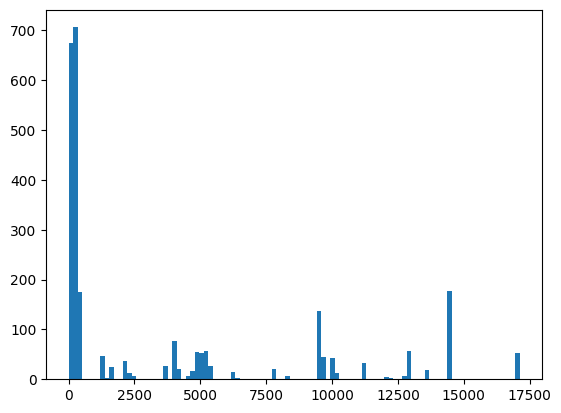

In [17]:
plt.hist(rows_with_zero, bins=100)

In [12]:
sum(df_mac['ENSG00000177757'] == 0)

77

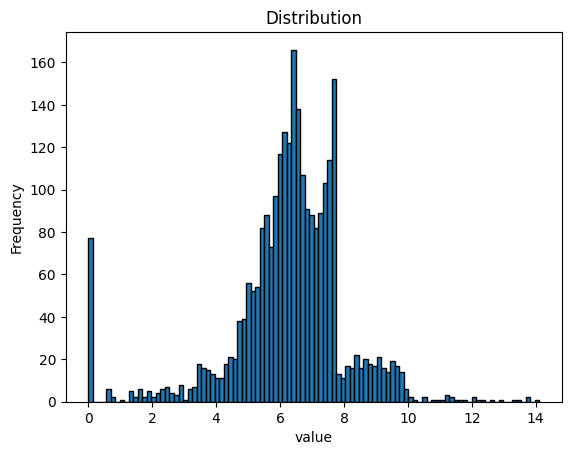

In [18]:
temp = df_mac['ENSG00000177757']
temp = np.log(1 + temp)


temp.plot(kind='hist', bins=100, edgecolor='black', title='Distribution')
plt.xlabel('value')
plt.ylabel('Frequency')
plt.show()

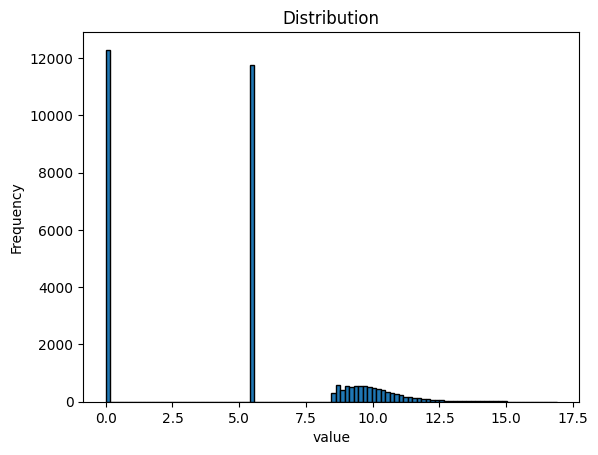

In [31]:
temp = df.loc['03d9eb203bc24f826a30525d2e4d155a___macrophage']

temp = np.log(1 + temp)


temp.plot(kind='hist', bins=100, edgecolor='black', title='Distribution')
plt.xlabel('value')
plt.ylabel('Frequency')
plt.show()

In [20]:
count_data = pd.read_csv('~/Python/raw_training_df.csv')
count_data

,genes,1611_GSM2027310,1611_GSM2027311,1611_GSM2027312,1611_GSM2027313,1611_GSM2027314,1611_GSM2027315,1611_GSM2027316,1611_GSM2027317,1611_GSM2027318,...,9780_GSM6107842,9780_GSM6107844,9786_GSM4819695,9786_GSM4819696,9798_Kolf2_iMacs_UT_16h_1_01,9798_Kolf2_iMacs_UT_16h_2_01,9798_Kolf2_iMacs_UT_16h_3_01,9798_Kolf2_iMacs_UT_6h_1_01,9798_Kolf2_iMacs_UT_6h_2_01,9798_Kolf2_iMacs_UT_6h_3_01
0,ENSG00000000003,0,5,0,3,0,26,0,1,0,...,3,0,13,7,28,38,54,37,46,63
1,ENSG00000000419,290,349,310,337,398,339,382,604,273,...,1123,878,473,358,159,248,271,227,261,284
2,ENSG00000000457,97,89,611,228,159,118,857,1120,154,...,344,523,256,253,33,33,23,33,18,20
3,ENSG00000000460,72,71,205,127,106,89,337,414,86,...,197,314,226,198,16,28,19,38,36,31
4,ENSG00000000938,11201,4231,56,2033,15270,3696,66,311,9690,...,14312,11290,348,292,216,241,329,160,241,437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27205,ENSG00000267796,86,88,74,74,110,60,110,172,78,...,444,345,121,121,2,1,3,3,2,4
27206,ENSG00000267797,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,1,0,0
27207,ENSG00000267799,1,0,0,0,0,2,0,1,0,...,0,0,0,0,0,0,0,0,0,0
27208,ENSG00000267800,4,2,6,8,12,3,14,19,5,...,7,3,1,4,0,0,0,0,0,0


In [21]:
sampegene_with_zero = (count_data == 0).sum(axis=0)

In [22]:
sampegene_with_zero

genes                              0
1611_GSM2027310                 5907
1611_GSM2027311                 6197
1611_GSM2027312                 6568
1611_GSM2027313                 5665
                                ... 
9798_Kolf2_iMacs_UT_16h_2_01    9210
9798_Kolf2_iMacs_UT_16h_3_01    8998
9798_Kolf2_iMacs_UT_6h_1_01     8978
9798_Kolf2_iMacs_UT_6h_2_01     9203
9798_Kolf2_iMacs_UT_6h_3_01     8594
Length: 555, dtype: int64

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  4.,  3.,  0.,  4.,
        11., 18., 13., 18., 21., 25., 35., 30., 35., 21., 20., 21., 21.,
        22., 19., 14., 22., 11., 11.,  7.,  8., 16.,  8.,  6.,  9.,  7.,
         9., 13.,  5.,  8.,  8.,  2.,  2.,  3.,  2.,  3.,  1.,  2.,  1.,
         2.,  4.,  0.,  4.,  2.,  3.,  6.,  0.,  3.,  3.,  1.,  1.,  1.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([    0.  ,   192.43,   384.86,   577.29,   769.72,   962.15,
         1154.58,  1347.01,  1539.44,  1731.87,  1924.3 ,  2116.73,
         2309.16,  2501.59,  2694.02,  2886.45,  3078.88,  3271.31,
         3463.74,  3656.17,  3848.6 ,  4041.03,  4233.46,  4425.89,
         4618.32,  4810.75,  5003.18,  5195.61,  5388.04,  5580.47,
         5772.9 ,  5965.33,  6157.76,  6350.19,  6542.62,  6735.05,
         6927.48,  7119.91

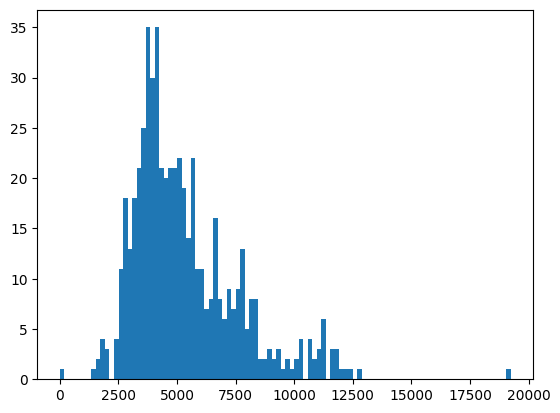

In [23]:
plt.hist(sampegene_with_zero, bins=100)

In [27]:
temp = count_data[count_data.genes == 'ENSG00000000003']

,genes,1611_GSM2027310,1611_GSM2027311,1611_GSM2027312,1611_GSM2027313,1611_GSM2027314,1611_GSM2027315,1611_GSM2027316,1611_GSM2027317,1611_GSM2027318,...,9780_GSM6107842,9780_GSM6107844,9786_GSM4819695,9786_GSM4819696,9798_Kolf2_iMacs_UT_16h_1_01,9798_Kolf2_iMacs_UT_16h_2_01,9798_Kolf2_iMacs_UT_16h_3_01,9798_Kolf2_iMacs_UT_6h_1_01,9798_Kolf2_iMacs_UT_6h_2_01,9798_Kolf2_iMacs_UT_6h_3_01
0,ENSG00000000003,0,5,0,3,0,26,0,1,0,...,3,0,13,7,28,38,54,37,46,63


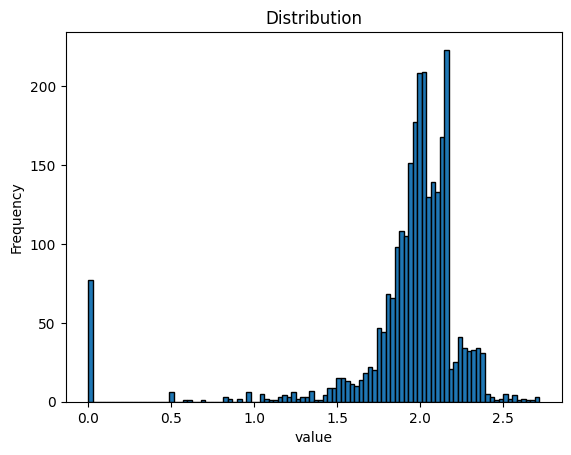

In [28]:
temp = np.log(1 + temp)


temp.plot(kind='hist', bins=100, edgecolor='black', title='Distribution')
plt.xlabel('value')
plt.ylabel('Frequency')
plt.show()

In [33]:
temp = count_data['1611_GSM2027310']

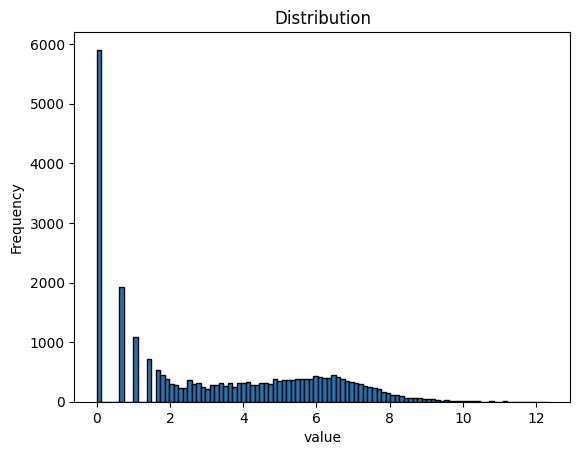

In [35]:
temp = np.log(1 + temp)


temp.plot(kind='hist', bins=100, edgecolor='black', title='Distribution')
plt.xlabel('value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
adata = sc.AnnData(df_mac)
adata.obs = adata.obs.merge(metadata, left_index=True, right_index=True, how='left')

In [17]:
import scvi
model = scvi.model.SCVI
model.setup_anndata(
    adata, 
    batch_key = 'assay_groups', 
    labels_key= 'tissue_groups', 
    categorical_covariate_keys = ['collection_id']
)


/home/chzhan1/.local/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning:

adata.X does not contain unnormalized count data. Are you sure this is what you want?

/home/chzhan1/.local/lib/python3.9/site-packages/scvi/data/fields/_dataframe_field.py:186: UserWarning:

Category 24 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.

/home/chzhan1/.local/lib/python3.9/site-packages/scvi/data/fields/_arraylike_field.py:410: UserWarning:

Category 13 in adata.obs['collection_id'] has fewer than 3 cells. Models may not train properly.



In [ ]:
import torch
device = 'gpu' if torch.cuda.is_available() else 'cpu'
device

In [19]:
model = scvi.model.SCVI(
    adata,
    n_hidden=256, n_layers=4, n_latent=3, gene_likelihood="nb",
    dropout_rate = 0.1, latent_distribution = 'norm', dispersion = 'gene'
)
    
model.train(
    plan_kwargs={'lr': 0.0006042174375915185},
    accelerator=device,
    max_epochs=300,
    early_stopping=True
)

/home/chzhan1/.local/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:191: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/chzhan1/.local/lib/python3.9/site-packages/ipy ...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/chzhan1/.local/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:191: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/chzhan1/.local/lib/python3.9/site-packages/ipy ...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/chzhan1/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/

Epoch 300/300: 100%|██████████| 300/300 [01:56<00:00,  2.53it/s, v_num=1, train_loss_step=3.32e+5, train_loss_epoch=3.26e+5]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 300/300: 100%|██████████| 300/300 [01:56<00:00,  2.56it/s, v_num=1, train_loss_step=3.32e+5, train_loss_epoch=3.26e+5]


In [20]:
scvi_matrix = model.get_latent_representation()


#scvi_matrix_full = model.get_normalized_expression()

scvi_matrix = pd.DataFrame(scvi_matrix)
scvi_matrix['sample_names'] = df.index
scvi_matrix = scvi_matrix.set_index('sample_names', drop = True)

scvi_matrix.columns = scvi_matrix.columns = ['V' + str(col) for col in scvi_matrix.columns]

scvi_representation_coordinates_merged = pd.merge(scvi_matrix, metadata, on='sample_names')

scvi_representation_coordinates_merged

,V0,V1,V2,sample_id,file_id_cellNexus,cell_type_consensus_harmonised,donor_id,dataset_id,collection_id,age_days,sex,ethnicity_groups,tissue_groups,assay_groups,disease_groups,n,age_days_scaled,age_bin_sex_specific
sample_names,,,,,,,,,,,,,,,,,,
03d9eb203bc24f826a30525d2e4d155a___macrophage,0.567218,0.902289,0.704470,03d9eb203bc24f826a30525d2e4d155a,000c86f0c82fd138b624a5da165ae676.h5ad,macrophage,donor_3,af8b241a-c72c-4470-b1a4-80e7336c6ab6,f8057c47-fcd8-4fcf-88b0-e2f930080f6e,28835,male,Other/Unknown,sensory-related structures,10x Genomics 3,Metabolic and Other Disorders,21,1.459434,Senior
70a3087e85d17f6a27a3cb6949190c21___macrophage,0.679973,1.162652,0.798298,70a3087e85d17f6a27a3cb6949190c21,000c86f0c82fd138b624a5da165ae676.h5ad,macrophage,donor_3,af8b241a-c72c-4470-b1a4-80e7336c6ab6,f8057c47-fcd8-4fcf-88b0-e2f930080f6e,28835,male,Other/Unknown,sensory-related structures,10x Genomics 3,Metabolic and Other Disorders,20,1.459434,Senior
129df572f839feb0392d1a386408fe6f___macrophage,0.555066,-0.631942,-1.082400,129df572f839feb0392d1a386408fe6f,004c0c87d698128c0d5a1154f9c1f627.h5ad,macrophage,H19.30.001,1185a7d3-a9c1-4280-9ba5-d61895b15cac,283d65eb-dd53-496d-adb7-7570c7caa443,15330,male,European,cerebral lobes and cortical areas,10x Genomics 3,Normal,69,0.775902,Middle Age
a654c8dcf70f0c397cec83474dc30eba___macrophage,0.563737,-0.009573,-0.847407,a654c8dcf70f0c397cec83474dc30eba,004c0c87d698128c0d5a1154f9c1f627.h5ad,macrophage,H19.30.002,1185a7d3-a9c1-4280-9ba5-d61895b15cac,283d65eb-dd53-496d-adb7-7570c7caa443,10585,male,European,cerebral lobes and cortical areas,10x Genomics 3,Normal,158,0.535742,Young Adulthood
cfe04fd6b8efbedb43298f57f8bb7531___macrophage,0.594855,0.043995,-0.781638,cfe04fd6b8efbedb43298f57f8bb7531,004c0c87d698128c0d5a1154f9c1f627.h5ad,macrophage,H18.30.002,1185a7d3-a9c1-4280-9ba5-d61895b15cac,283d65eb-dd53-496d-adb7-7570c7caa443,18250,male,European,cerebral lobes and cortical areas,10x Genomics 3,Normal,121,0.923692,Middle Age
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30a4dd504f38aa7e36ce0324d5372944___10X390_3:___macrophage,0.614920,-0.781914,-1.049844,30a4dd504f38aa7e36ce0324d5372944___10X390_3:,ffe3470cbfa9a83dc525f0c5096b43a2.h5ad,macrophage,H19.30.001,900fdf13-150d-4695-9f8c-4c09105ba2eb,283d65eb-dd53-496d-adb7-7570c7caa443,15330,male,European,brainstem and cerebellar structures,10x Genomics 3,Normal,77,0.775902,Middle Age
30a4dd504f38aa7e36ce0324d5372944___10X390_4:___macrophage,0.606841,-1.151177,-1.179539,30a4dd504f38aa7e36ce0324d5372944___10X390_4:,ffe3470cbfa9a83dc525f0c5096b43a2.h5ad,macrophage,H19.30.001,900fdf13-150d-4695-9f8c-4c09105ba2eb,283d65eb-dd53-496d-adb7-7570c7caa443,15330,male,European,brainstem and cerebellar structures,10x Genomics 3,Normal,53,0.775902,Middle Age
917e1b245e4fc39bad40fc511a774b71___macrophage,0.474058,0.274025,-0.931247,917e1b245e4fc39bad40fc511a774b71,ffe3470cbfa9a83dc525f0c5096b43a2.h5ad,macrophage,H19.30.002,900fdf13-150d-4695-9f8c-4c09105ba2eb,283d65eb-dd53-496d-adb7-7570c7caa443,10585,male,European,brainstem and cerebellar structures,10x Genomics 3,Normal,383,0.535742,Young Adulthood


In [21]:
import plotly.express as px

# Plotting
fig = px.scatter_3d(
    scvi_representation_coordinates_merged,
    x='V0',
    y='V1',
    z='V2',
    color= 'tissue_groups'
)

# Adjusting marker size
fig.update_traces(marker=dict(size=4))

# Show the plot
fig.show()

In [22]:
de_lfc = model.differential_expression(groupby='tissue_groups')

DE...: 100%|██████████| 26/26 [03:37<00:00,  8.38s/it]


In [23]:
de_lfc

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
ENSG00000255270,0.9962,0.0038,5.568944,2.199904e-05,1.713301e-06,0.0,0.25,15.037725,19.420155,15.652727,...,88140.128257,2853.462862,0.921875,0.414738,0.444574,0.014766,True,adipose tissue vs Rest,adipose tissue,Rest
ENSG00000265477,0.9954,0.0046,5.377086,7.545386e-05,8.637830e-06,0.0,0.25,15.883527,21.478600,15.416167,...,250753.257090,21507.204888,0.921875,0.414738,1.227595,0.107281,True,adipose tissue vs Rest,adipose tissue,Rest
ENSG00000253184,0.9952,0.0048,5.334326,1.042142e-05,1.932654e-06,0.0,0.25,6.833534,3.917661,11.852036,...,13008.021563,2669.801968,0.921875,0.743056,0.107280,0.017748,True,adipose tissue vs Rest,adipose tissue,Rest
ENSG00000287358,0.9952,0.0048,5.334326,7.670592e-08,3.000219e-07,0.0,0.25,4.541093,4.484905,14.957599,...,77.191857,394.243784,0.343750,0.306327,0.000589,0.002535,True,adipose tissue vs Rest,adipose tissue,Rest
ENSG00000287415,0.9950,0.0050,5.293303,4.629751e-06,2.963738e-07,0.0,0.25,7.693774,4.946237,18.786482,...,3952.882650,365.358154,0.343750,0.300926,0.030076,0.002593,True,adipose tissue vs Rest,adipose tissue,Rest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000130935,0.5604,0.4396,0.242786,1.842629e-05,1.986060e-05,0.0,0.25,-0.014822,-0.065246,0.858594,...,28485.409487,22287.906567,1.000000,1.000000,0.268661,0.173296,False,trachea vs Rest,trachea,Rest
ENSG00000119414,0.5582,0.4418,0.233860,4.067974e-05,3.866817e-05,0.0,0.25,0.158924,0.091079,1.199527,...,45046.778904,46969.534060,1.000000,1.000000,0.360715,0.366074,False,trachea vs Rest,trachea,Rest
ENSG00000124422,0.5554,0.4446,0.222514,4.415483e-05,4.538741e-05,0.0,0.25,0.001063,-0.015060,0.919064,...,37921.761742,55013.757802,1.000000,1.000000,0.315245,0.423477,False,trachea vs Rest,trachea,Rest
ENSG00000116750,0.5548,0.4452,0.220084,2.734088e-05,2.736045e-05,0.0,0.25,0.141813,0.030988,1.059613,...,37892.338410,32060.545941,1.000000,1.000000,0.277777,0.250709,False,trachea vs Rest,trachea,Rest


In [29]:
de_lfc.columns

Index(['proba_de', 'proba_not_de', 'bayes_factor', 'scale1', 'scale2',
       'pseudocounts', 'delta', 'lfc_mean', 'lfc_median', 'lfc_std', 'lfc_min',
       'lfc_max', 'raw_mean1', 'raw_mean2', 'non_zeros_proportion1',
       'non_zeros_proportion2', 'raw_normalized_mean1', 'raw_normalized_mean2',
       'is_de_fdr_0.05', 'comparison', 'group1', 'group2'],
      dtype='object')

In [33]:
markers = {}
cats = adata.obs.tissue_groups.unique().tolist()
cats

['sensory-related structures',
 'cerebral lobes and cortical areas',
 'breast',
 'nasal, oral, and pharyngeal regions',
 'gastrointestinal accessory organs',
 'blood',
 'brainstem and cerebellar structures',
 'limbic and basal systems',
 'epithelium and mucosal tissues',
 'small intestine',
 'respiratory system',
 'lymphatic system',
 'large intestine',
 'prostate',
 'bone marrow',
 'spleen',
 'adipose tissue',
 'endocrine system',
 'renal system',
 'trachea',
 'cardiovascular system',
 'integumentary system (skin)',
 'female reproductive system',
 'oesophagus',
 'stomach',
 'general brain and major structures']

In [36]:
for i, c in enumerate(cats):
    cid = "{} vs Rest".format(c)
    tissue_group_df = de_lfc.loc[de_lfc.comparison == cid]
    
    tissue_group_df = tissue_group_df[tissue_group_df.lfc_mean > 0]
    
    tissue_group_df = tissue_group_df[tissue_group_df["bayes_factor"] > 3]
    tissue_group_df = tissue_group_df[tissue_group_df["non_zeros_proportion1"] > 0.1]
    
    markers[c] = tissue_group_df.index.tolist()[:3]

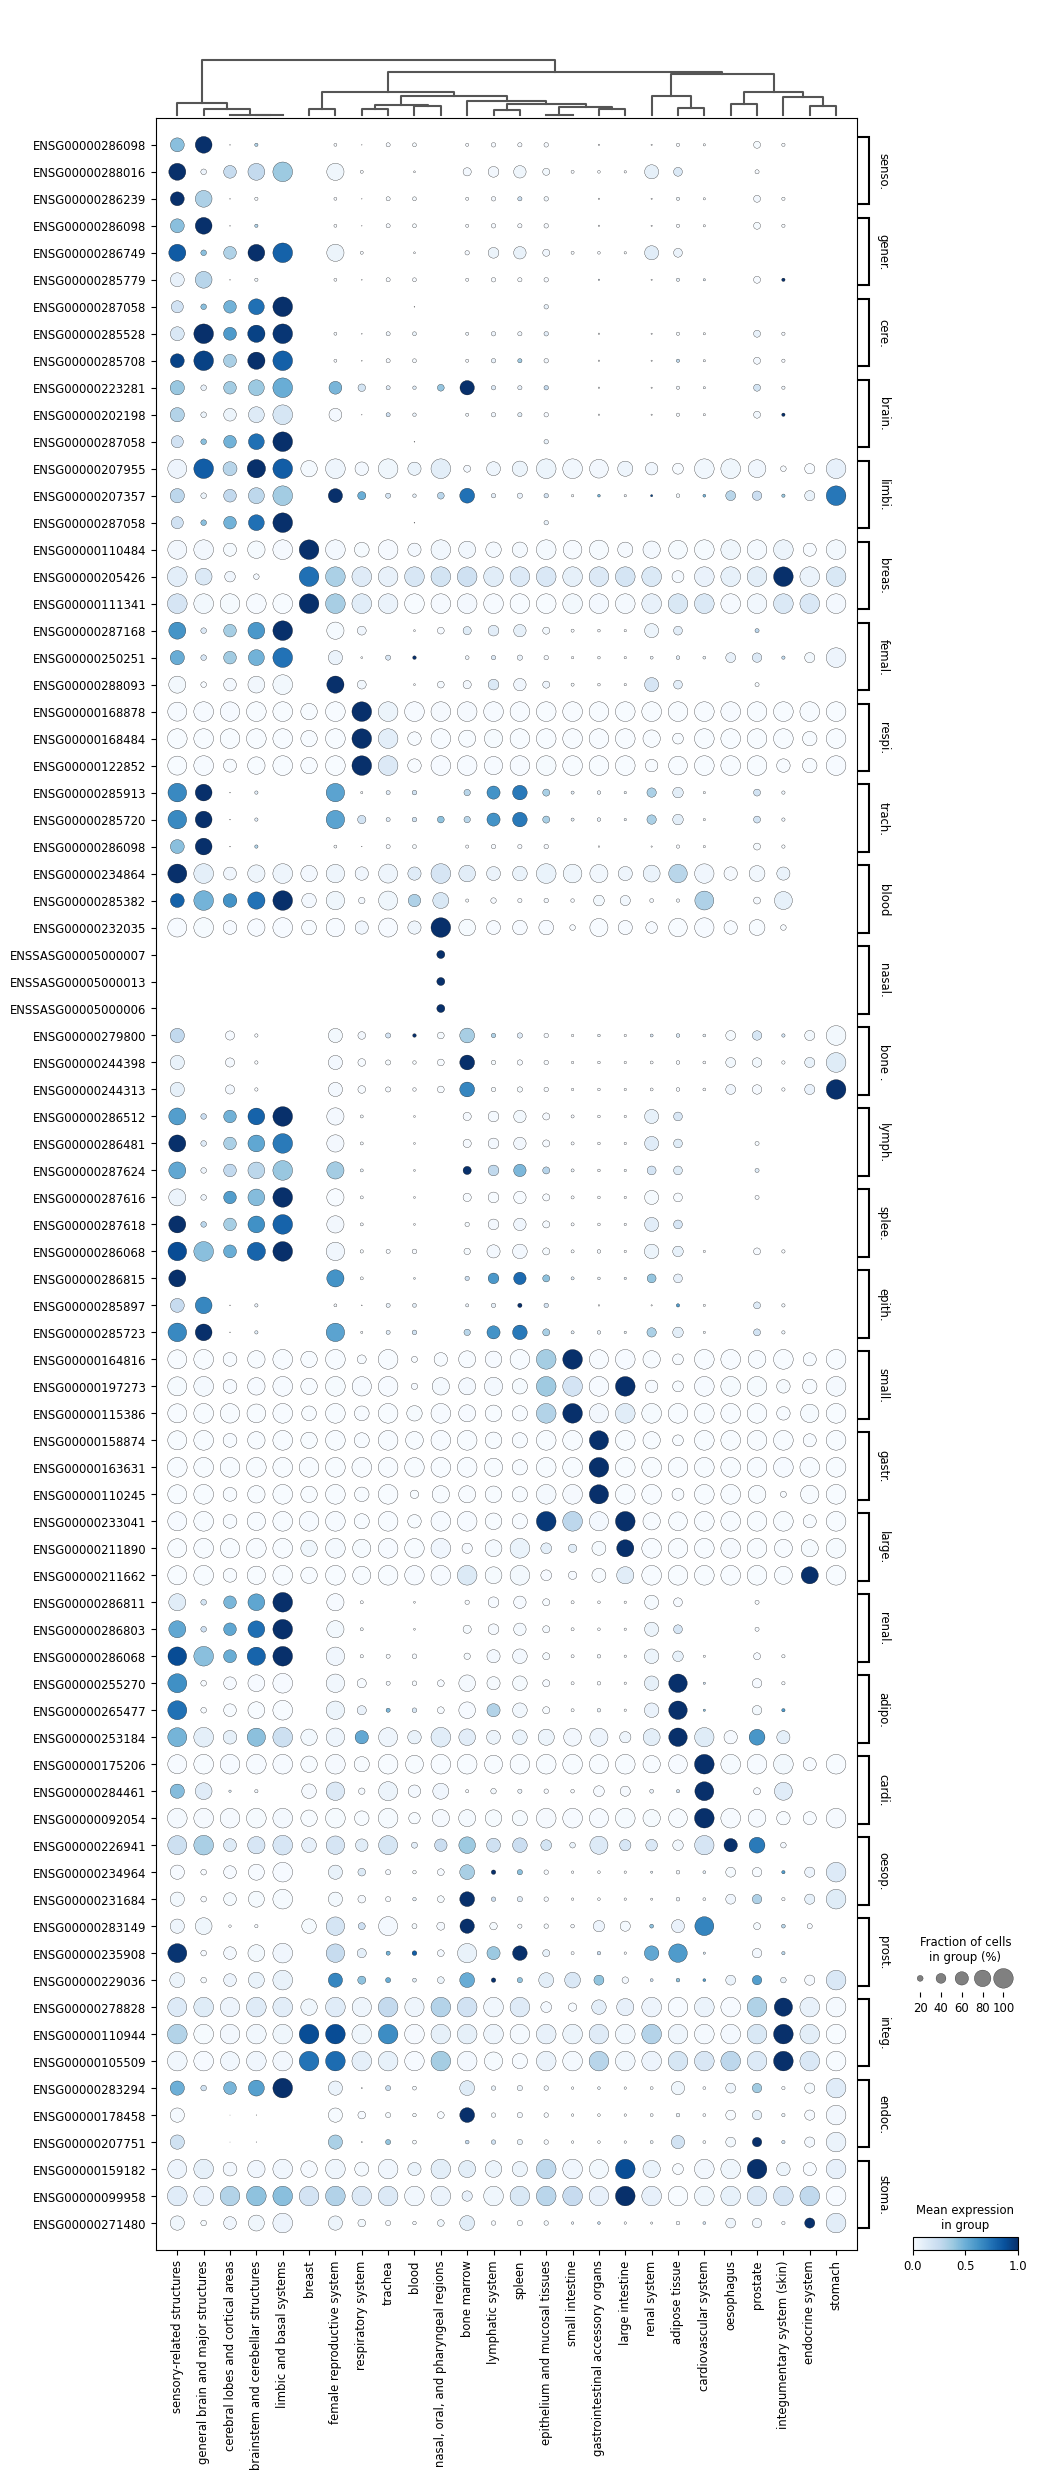

In [57]:
sc.pl.dotplot(
    adata,
    markers,
    groupby = "tissue_groups",
    dendrogram = True,
    color_map = "Blues",
    swap_axes = True,
    standard_scale = "var",
    save = 'demo_de_marker_genes_by_tissue_groups.pdf'
)

In [50]:
adata

AnnData object with n_obs × n_vars = 2656 × 60621
    obs: 'sample_id', 'file_id_cellNexus', 'cell_type_consensus_harmonised', 'donor_id', 'dataset_id', 'collection_id', 'age_days', 'sex', 'ethnicity_groups', 'tissue_groups', 'assay_groups', 'disease_groups', 'n', 'age_days_scaled', 'age_bin_sex_specific', '_scvi_batch', '_scvi_labels', '_scvi_raw_norm_scaling'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'dendrogram_tissue_groups'
    obsm: '_scvi_extra_categorical_covs', 'X_pca'

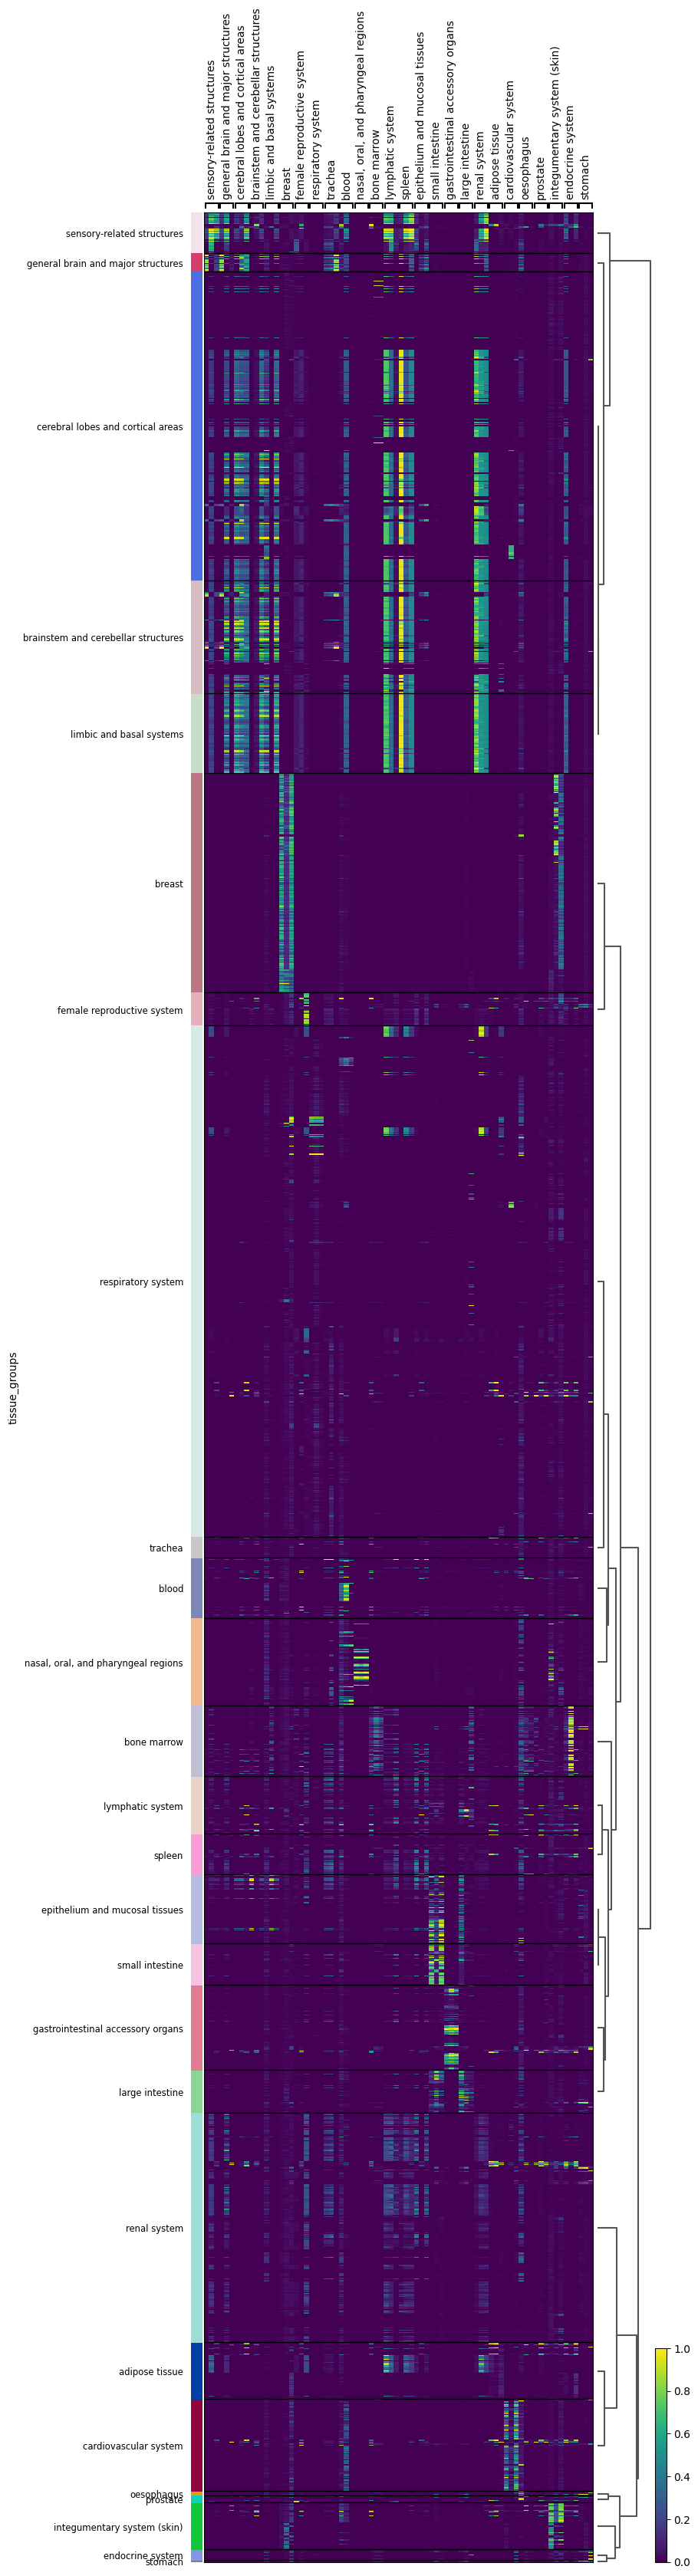

In [56]:
adata.layers["scvi_normalized"] = model.get_normalized_expression()
sc.pl.heatmap(
    adata,
    markers,
    groupby = "tissue_groups",
    layer = "scvi_normalized",
    standard_scale = "var",
    dendrogram = True,
    figsize = (8, 40)
)